# Control Systems Simulator (CSSIM)

Maurício Shoji Sugahara Pires

Orientador: Prof. Markus Vinícius Santos Lima

Departamento de Engenharia Elétrica - UFRJ

## Fundamentação teórica

Esta primeira parte apresenta a base conceitual necessária para entender o que o CSSIM faz antes da simulação numérica. A ideia é separar claramente:

1. **a teoria geral**, isto é, como diagramas de blocos podem ser descritos em espaço de estados;
2. **a aplicação ao exemplo**, feita depois no sistema de primeira ordem do arquivo `diagrams/first_order_step.json`.

Do ponto de vista de controle, um mesmo sistema pode ser estudado por função de transferência, no domínio de Laplace, ou por equações de estado, no domínio do tempo. O CSSIM precisa da segunda forma, porque o integrador numérico trabalha com equações diferenciais ordinárias explícitas.

Em outras palavras, o simulador não integra diretamente uma função de transferência. Ele precisa construir uma expressão do tipo

$$
\dot{\mathbf{x}}(t)=f\bigl(t,\mathbf{x}(t)\bigr),
$$

na qual a derivada dos estados possa ser calculada a cada instante. Portanto, a tarefa central do CSSIM é transformar a estrutura do diagrama em um modelo matemático equivalente, pronto para integração numérica.

### 1. Ideia central: por que usar espaço de estados?

Na forma de espaço de estados, o comportamento dinâmico do sistema é descrito por variáveis internas chamadas **estados**. Essas variáveis representam a memória do sistema e permitem escrever a dinâmica diretamente no tempo.

A forma padrão é

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}\,\mathbf{u}(t),
$$

$$
\mathbf{y}(t)=\mathbf{C}\,\mathbf{x}(t)+\mathbf{D}\,\mathbf{u}(t).
$$

em que:

- $\mathbf{x}(t)$ é o vetor de estados;
- $\mathbf{u}(t)$ é o vetor de entradas;
- $\mathbf{y}(t)$ é o vetor de saídas;
- $\mathbf{A},\mathbf{B},\mathbf{C},\mathbf{D}$ são as matrizes do modelo.

Neste notebook, para manter a simbologia tradicional de espaço de estados, a letra $\mathbf{y}(t)$ fica reservada para a **saída externa do sistema**. Quando for necessário representar sinais internos algébricos da interconexão, será usada a notação $\mathbf{w}(t)$. Da mesma forma, a letra $G$ fica reservada para **função de transferência**, como em $G(s)$.

Essa distinção é importante porque o CSSIM precisa separar:

- a dinâmica associada aos estados;
- as entradas externas aplicadas ao sistema;
- os sinais internos produzidos pela interconexão entre blocos.

### 2. O que o CSSIM faz, em termos conceituais

Ao ler um diagrama, o CSSIM separa os blocos em dois grupos principais:

1. **blocos dinâmicos**, que introduzem estados;
2. **blocos algébricos**, que apenas combinam sinais instantaneamente.

Isso leva naturalmente a duas camadas matemáticas:

- uma camada **algébrica**, que resolve sinais internos como somas, ganhos e realimentações;
- uma camada **dinâmica**, que calcula $\dot{\mathbf{x}}(t)$ a partir dos estados e dos sinais já resolvidos.

De forma resumida, o CSSIM segue 10 etapas:

1. lê o JSON do diagrama;
2. constrói o grafo de interconexões;
3. resolve parâmetros simbólicos;
4. identifica quais blocos têm estado;
5. converte blocos dinâmicos para matrizes de espaço de estados;
6. monta o acoplamento algébrico entre os sinais;
7. produz a função $f(t,\mathbf{x})$ usada pelo integrador;
8. executa a simulação;
9. reconstrói e visualiza as saídas;
10. integra o diagrama ao notebook.

As principais funções envolvidas nesse processo são:

- `load_json(...)`;
- `build_graph(...)`;
- `set_parameters(...)`;
- `resolve_param(...)`;
- `categorize_blocks(...)`;
- `tf_to_ss(...)`;
- `build_solver(...)`;
- `compute_rhs(...)`;
- `generate_input_signal(...)`;
- `run_simulation(...)`;
- `plot_signals(...)`;
- `open_gui(...)`.

Neste notebook, o exemplo adotado é o sistema de primeira ordem definido em `diagrams/first_order_step.json`, para o qual a malha fechada satisfaz

$$
E(s)=R(s)-C(s), \qquad G(s)=\frac{1}{Ts}, \qquad \frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

A próxima parte mostra como essa teoria é aplicada, passo a passo, a esse exemplo.

## Exemplo de primeira ordem

Depois da base teórica, passamos ao exemplo usado ao longo do notebook. Considerando o sistema de primeira ordem mostrado no diagrama, a relação entrada-saída em malha fechada é

$$
\frac{C(s)}{R(s)} = \frac{1}{Ts + 1}.
$$

Para entrada degrau unitário, com condições iniciais nulas, temos

$$
R(s)=\frac{1}{s},
$$

e então

$$
C(s)=\frac{1}{Ts+1}\,\frac{1}{s}.
$$

Fazendo a expansão em frações parciais e aplicando a transformada inversa de Laplace, obtemos

$$
c(t)=1-e^{-t/T}, \qquad t\ge 0.
$$

Esse resultado analítico servirá como referência ao longo do notebook. A partir daqui, o objetivo é mostrar como o CSSIM reconstrói exatamente esse comportamento a partir do diagrama de blocos e da formulação em espaço de estados.

## Fluxo no CSSIM

A seguir, o arquivo `diagrams/first_order_step.json` é analisado no mesmo fluxo usado pelo CSSIM para transformar um diagrama de blocos em um modelo em espaço de estados.

No exemplo, a malha fechada satisfaz

$$
E(s)=R(s)-C(s), \qquad G(s)=\frac{1}{Ts}, \qquad \frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

Do ponto de vista do simulador, a ideia central é:

1. identificar a topologia do diagrama;
2. separar blocos dinâmicos e blocos algébricos;
3. converter os blocos dinâmicos para espaço de estados;
4. resolver os sinais internos da interconexão;
5. obter uma EDO explícita para integração numérica.

As etapas abaixo seguem a mesma organização do documento teórico `modelo_matematico_cssim.md`.

In [1]:
from pprint import pprint
import inspect
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Math

from cssim import (
    load_json,
    build_graph,
    set_parameters,
    resolve_param,
    categorize_blocks,
    tf_to_ss,
    build_solver,
    compute_rhs,
    generate_input_signal,
    run_simulation,
    plot_signals,
    open_gui,
)

s = sp.Symbol("s")
diagram_path = "diagrams/first_order_step.json"
T = 1
param_values = {"T": T}
set_parameters(param_values)

data = load_json(diagram_path)
print("diagram_path =", diagram_path)
print("param_values =", param_values)
print("Tipo de data =", type(data).__name__)

diagram_path = diagrams/first_order_step.json
param_values = {'T': 1}
Tipo de data = dict


### Etapa 1 — Leitura do diagrama com `load_json(...)`

Função usada: `load_json(diagram_path)`.

**Entrada**

- `diagram_path`: caminho do arquivo JSON.

**Saída**

- `data`: dicionário com `blocks`, `connections`, `sim_time` e `step_size`.

Nesta etapa, o CSSIM ainda não monta equações de estado. Ele apenas lê a descrição estrutural do sistema: quais blocos existem, como eles estão conectados e quais parâmetros de simulação devem ser usados.

Nesse arquivo, os blocos representam a entrada, o somador, a função de transferência e a saída. Em termos de controle clássico, o diagrama codifica as relações

$$
R(s)=\frac{1}{s}, \qquad E(s)=R(s)-C(s), \qquad G(s)=\frac{1}{Ts}, \qquad C(s)=G(s)E(s).
$$

Ou seja, esta etapa identifica a topologia física que depois será convertida em relações algébricas e dinâmicas.

In [2]:
input_block = next(b for b in data["blocks"] if b["type"] == "input")
operation_block = next(b for b in data["blocks"] if b["type"] == "operation")
tf_block = next(b for b in data["blocks"] if b["type"] == "transfer_function")
output_block = next(b for b in data["blocks"] if b["type"] == "output")

print("Entrada de load_json():", diagram_path)
print("Saída de load_json(): data")
print("Chaves principais =", list(data.keys()))
print("Número de blocos =", len(data["blocks"]))
print("Número de conexões =", len(data["connections"]))

pprint(
    {
        "input": input_block["attributes"],
        "operation": operation_block["attributes"],
        "transfer_function": tf_block["attributes"],
        "output": output_block["attributes"],
    }
)

display(Math(r"R(s)=\frac{1}{s}"))
display(Math(r"E(s)=R(s)-C(s)"))
display(Math(r"G(s)=\frac{1}{Ts}"))
display(Math(r"C(s)=G(s)E(s)"))

Entrada de load_json(): diagrams/first_order_step.json
Saída de load_json(): data
Chaves principais = ['blocks', 'connections', 'sim_time', 'step_size']
Número de blocos = 4
Número de conexões = 5
{'input': {'data-a': '1',
           'data-a0': '0',
           'data-f': '',
           'data-m': '',
           'data-name': 'Entrada',
           'data-offset': '',
           'data-phase': '',
           'data-signal': 'step',
           'data-t0': '0'},
 'operation': {'data-name': '',
               'data-operator-1': '+',
               'data-operator-2': '-',
               'data-position': 'bottom'},
 'output': {'data-name': 'Saída'},
 'transfer_function': {'data-denominator': 'T*s',
                       'data-name': 'Função de transferência',
                       'data-numerator': '1'}}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Etapa 2 — Construção do grafo com `build_graph(...)`

Função usada: `build_graph(data)`.

**Entrada**

- `data`: estrutura lida do JSON.

**Saída**

- `G`: grafo direcionado com blocos como nós e fluxos de sinal como arestas.

No grafo, a estrutura física do diagrama é convertida em uma estrutura computacional. Essa etapa é importante porque o simulador precisa saber:

- de onde vem cada sinal;
- para onde cada sinal vai;
- quais blocos alimentam outros blocos;
- onde existe realimentação.

No exemplo, o grafo deixa explícita a sequência entrada → somador → bloco dinâmico → saída, com a saída retornando ao somador. Essa informação será usada depois para montar as equações algébricas e a dinâmica do sistema.

In [3]:
G = build_graph(data)

block_types = {block["id"]: block["type"] for block in data["blocks"]}

print("Entrada de build_graph(): data")
print("Saída de build_graph(): G")
print("Nós do grafo:", list(G.nodes))
print("Tipo de bloco:")
for node in G.nodes:
    print(f"  {node}: {block_types.get(node)}")
print("Arestas do grafo:")
for u, v, attrs in G.edges(data=True):
    print(f"  {u} -> {v}  position={attrs.get('position')}")


Entrada de build_graph(): data
Saída de build_graph(): G
Nós do grafo: ['Block0', 'Block1', 'Block2', 'Block3']
Tipo de bloco:
  Block0: input
  Block1: operation
  Block2: transfer_function
  Block3: output
Arestas do grafo:
  Block0 -> Block1  position=left
  Block1 -> Block2  position=left
  Block2 -> Block3  position=left
  Block2 -> Block1  position=bottom


### Etapa 3 — Resolução dos parâmetros com `set_parameters(...)` e `resolve_param(...)`

Função usada: `resolve_param(expr, allow_s=False, default=None)`.

**Entrada**

- expressões simbólicas do diagrama, como `"T"`.

**Saída**

- valores numéricos usados pelo simulador.

Neste exemplo, o parâmetro simbólico é a constante de tempo $T$. Ao resolver esse parâmetro, a representação simbólica do bloco

$$
G(s)=\frac{1}{Ts}
$$

passa a usar o valor numérico definido no notebook. Isso é importante porque a conversão para espaço de estados exige coeficientes numéricos nas matrizes do modelo.

Assim, com $T=1$, o bloco passa a ser interpretado numericamente como

$$
G(s)=\frac{1}{s}.
$$

In [4]:
T_expr = "T"
T_value = resolve_param(T_expr, default=None)
num_expr = tf_block["attributes"]["data-numerator"]
den_expr = tf_block["attributes"]["data-denominator"]
num_sym = sp.sympify(num_expr, locals={"s": s})
den_sym = sp.sympify(den_expr, locals={"T": T_value, "s": s})

print("Entrada de resolve_param():", T_expr)
print("Saída de resolve_param():", T_value)
print("Numerador simbólico =", num_expr)
print("Denominador simbólico =", den_expr)
print("Denominador com parâmetro resolvido =", den_sym)

display(Math(r"T=%s" % sp.latex(T_value)))
display(Math(r"G(s)=\frac{%s}{%s}" % (sp.latex(num_sym), sp.latex(den_sym))))

Entrada de resolve_param(): T
Saída de resolve_param(): 1.0
Numerador simbólico = 1
Denominador simbólico = T*s
Denominador com parâmetro resolvido = 1.0*s


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Etapa 4 — Categorização dos blocos com `categorize_blocks(...)`

Função usada: `categorize_blocks(data, G, param_values)`.

**Entrada**

- `data`: diagrama em JSON.
- `G`: grafo do diagrama.
- `param_values`: parâmetros já resolvidos, aqui `{"T": T}`.

**Saída**

- `input_blocks`, `tf_blocks`, `static_blocks`, `pid_blocks`, `output_blocks` e `total_states`.

Nessa etapa, cada bloco do diagrama recebe um papel no modelo matemático:

- o bloco de entrada representa a entrada externa $u(t)$, que neste exemplo coincide com a referência $r(t)$;
- o somador é um bloco algébrico e produz o erro $e(t)=r(t)-c(t)$;
- o bloco dinâmico representa a planta $G(s)=\frac{1}{Ts}$ e introduz estados;
- o bloco de saída apenas seleciona o sinal observado ao final.

Como existe apenas um bloco dinâmico de primeira ordem, o sistema total possui um único estado. Por isso, o vetor global de estados tem dimensão 1 e pode ser escrito como $\mathbf{x}(t)=x(t)$.

In [5]:
(
    input_blocks,
    tf_blocks,
    static_blocks,
    pid_blocks,
    output_blocks,
    total_states,
) = categorize_blocks(data, G, param_values=param_values)

print("categorize_blocks(data, G, param_values)")
print("input_blocks =", input_blocks)
print("tf_blocks =", [block["id"] for block in tf_blocks])
print("static_blocks =", [block["id"] for block in static_blocks])
print("pid_blocks =", pid_blocks)
print("output_blocks =", output_blocks)
print("total_states =", total_states)

categorize_blocks(data, G, param_values)
input_blocks = ['Block0']
tf_blocks = ['Block2']
static_blocks = ['Block1']
pid_blocks = []
output_blocks = ['Block3']
total_states = 1


### Etapa 5 — Da função de transferência para espaço de estados com `tf_to_ss(...)`

Função usada: `tf_to_ss(num, den, param_values=None)`.

**Entrada**

- `num = "1"`
- `den = "T*s"`
- `param_values = {"T": T}`

**Saída**

- matrizes `A`, `B`, `C`, `D` do bloco dinâmico.

Para a função de transferência

$$
G(s)=\frac{C(s)}{E(s)}=\frac{1}{Ts},
$$

a representação em espaço de estados pode ser escrita como

$$
\dot{x}(t)=A x(t)+B e(t), \qquad c(t)=C x(t)+D e(t).
$$

No caso deste exemplo, o bloco funciona como um integrador escalado. Mantendo $T$ explícito, a interpretação física é

$$
\dot{x}(t)=e(t), \qquad c(t)=\frac{1}{T}x(t).
$$

Ou seja, o estado $x(t)$ guarda a memória do integrador, e a saída do bloco é obtida a partir desse estado.

In [6]:
A_tf, B_tf, C_tf, D_tf = tf_to_ss(
    tf_block["attributes"]["data-numerator"],
    tf_block["attributes"]["data-denominator"],
    param_values=param_values,
)

tf_info = tf_blocks[0]

print("Entrada de tf_to_ss():", tf_block["attributes"]["data-numerator"], "/", tf_block["attributes"]["data-denominator"])
print("A =\n", A_tf)
print("B =\n", B_tf)
print("C =\n", C_tf)
print("D =", D_tf)
# print("state_slice =", tf_info["state_slice"])


Entrada de tf_to_ss(): 1 / T*s
A =
 [[-0.]]
B =
 [[1.]]
C =
 [[1.]]
D = 0.0


### Etapa 6 — Montagem do modelo completo com `build_solver(...)` e `compute_rhs(...)`

Funções usadas: `build_solver(...)` e `compute_rhs(...)`.

**Entrada de `build_solver(...)`**

- `input_blocks`, `static_blocks`, `tf_blocks`, `pid_blocks`, `total_states`.

**Saída de `build_solver(...)`**

- `w_ids`, `w_index`, `u_ids`, `u_index`, `M_inv`, `P`, `H`.

**Entrada de `compute_rhs(...)`**

- sinais de entrada, blocos dinâmicos e estruturas algébricas do sistema.

**Saída de `compute_rhs(...)`**

- `rhs(t, x)`, a dinâmica do sistema para integração numérica.

Esta é a etapa central do CSSIM. Depois que cada bloco dinâmico já foi convertido para espaço de estados, ainda falta combinar todos os blocos do diagrama em um único modelo global.

#### Parte algébrica: resolver os sinais internos

Blocos como somadores, ganhos e conexões não criam novos estados. Eles apenas impõem relações instantâneas entre sinais. O CSSIM reúne essas relações em um sistema do tipo

$$
\mathbf{M}\,\mathbf{w}(t)=\mathbf{H}\,\mathbf{x}(t)+\mathbf{P}\,\mathbf{u}(t).
$$

em que:

- $\mathbf{x}(t)$ é o vetor global de estados;
- $\mathbf{u}(t)$ é o vetor de entradas externas;
- $\mathbf{w}(t)$ reúne sinais internos relevantes da interconexão;
- $\mathbf{M}$ descreve o acoplamento algébrico entre esses sinais;
- $\mathbf{H}$ mostra como os estados influenciam as equações algébricas;
- $\mathbf{P}$ mostra como as entradas externas aparecem nessas equações algébricas.

Se $\mathbf{M}$ é inversível, então

$$
\mathbf{w}(t)=\mathbf{M}^{-1}\bigl(\mathbf{H}\,\mathbf{x}(t)+\mathbf{P}\,\mathbf{u}(t)\bigr).
$$

Em linguagem simples: dado o estado atual e a entrada atual, o CSSIM calcula instantaneamente os sinais internos necessários para fechar a malha.

#### Parte dinâmica: calcular a derivada dos estados

Depois de conhecer os sinais internos, o CSSIM calcula a dinâmica global na forma

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}_w\,\mathbf{w}(t)+\mathbf{B}_u\,\mathbf{u}(t).
$$

Essa expressão surge da montagem das equações locais de cada bloco dinâmico. Para um bloco dinâmico isolado $i$, a forma usual de espaço de estados é

$$
\dot{\mathbf{x}}_i(t)=\mathbf{A}_i\,\mathbf{x}_i(t)+\mathbf{B}_i\,\mathbf{u}_i(t),
$$

$$
\mathbf{y}_i(t)=\mathbf{C}_i\,\mathbf{x}_i(t)+\mathbf{D}_i\,\mathbf{u}_i(t).
$$

Quando o diagrama possui vários blocos dinâmicos, o CSSIM empilha todos os estados em um único vetor global:

$$
\mathbf{x}(t)=\begin{pmatrix}
\mathbf{x}_1(t) \\
\mathbf{x}_2(t) \\
\vdots \\
\mathbf{x}_n(t)
\end{pmatrix}.
$$

A partir daí, todas as equações diferenciais locais são reunidas em uma única equação global. Por isso, a derivada do vetor de estados pode depender:

1. do próprio estado atual $\mathbf{x}(t)$;
2. dos sinais internos $\mathbf{w}(t)$;
3. das entradas externas $\mathbf{u}(t)$.

Em alguns textos aparece apenas a forma clássica

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}\,\mathbf{u}(t).
$$

No CSSIM, a separação entre $\mathbf{w}(t)$ e $\mathbf{u}(t)$ é mantida explicitamente porque a entrada de um bloco dinâmico muitas vezes não vem diretamente de uma entrada externa, mas sim da saída de um somador, de um ganho ou de uma realimentação.

Substituindo a solução algébrica de $\mathbf{w}(t)$ na parte dinâmica, obtemos

$$
\dot{\mathbf{x}}(t)=\bigl(\mathbf{A}+\mathbf{B}_w\,\mathbf{M}^{-1}\mathbf{H}\bigr)\mathbf{x}(t)+\bigl(\mathbf{B}_w\,\mathbf{M}^{-1}\mathbf{P}+\mathbf{B}_u\bigr)\mathbf{u}(t).
$$

Se redefinirmos as matrizes efetivas do sistema completo por

$$
\mathbf{A}\coloneqq \mathbf{A}+\mathbf{B}_w\,\mathbf{M}^{-1}\mathbf{H},
\qquad
\mathbf{B}\coloneqq \mathbf{B}_w\,\mathbf{M}^{-1}\mathbf{P}+\mathbf{B}_u,
$$

o modelo volta à forma clássica

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}\,\mathbf{u}(t).
$$

Se desejado, a saída externa pode ser escrita como

$$
\mathbf{y}(t)=\mathbf{C}\,\mathbf{x}(t)+\mathbf{D}\,\mathbf{u}(t).
$$

#### Aplicação da etapa 6 ao exemplo de primeira ordem

No exemplo deste notebook, existe apenas um estado. Portanto, no caso geral $\mathbf{x}(t)$ é um vetor, mas aqui ele se reduz ao escalar

$$
\mathbf{x}(t)=x(t).
$$

A entrada externa é a referência, então

$$
\mathbf{u}(t)=r(t).
$$

Os sinais internos relevantes são escolhidos como

$$
\mathbf{w}(t)=\begin{bmatrix} e(t) \\ c(t) \end{bmatrix},
$$

em que $e(t)$ é o erro na saída do somador e $c(t)$ é a saída interna da planta. As relações literais do diagrama são

$$
e(t)=r(t)-c(t)
$$

e

$$
c(t)=\frac{1}{T}x(t).
$$

Escrevendo a primeira relação como $e(t)+c(t)=r(t)$, obtemos a forma matricial:

$$
\mathbf{w}(t)=\begin{bmatrix} e(t) \\ c(t) \end{bmatrix}
$$

$$
\mathbf{M}=\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}
$$

$$
\mathbf{H}=\begin{bmatrix} 0 \\ \frac{1}{T} \end{bmatrix}
$$

$$
\mathbf{P}=\begin{bmatrix} 1 \\ 0 \end{bmatrix}
$$

Assim, a equação algébrica do exemplo fica

$$
\mathbf{M}\,\mathbf{w}(t)=\mathbf{H}\,x(t)+\mathbf{P}\,r(t).
$$

Como $\mathbf{M}$ é inversível, o CSSIM calcula

$$
\mathbf{w}(t)=\mathbf{M}^{-1}\bigl(\mathbf{H}x(t)+\mathbf{P}r(t)\bigr),
$$

com

$$
\mathbf{M}^{-1}=\begin{pmatrix}1 & -1 \\ 0 & 1\end{pmatrix}.
$$

Isso devolve exatamente

$$
e(t)=r(t)-\frac{1}{T}x(t),
\qquad
c(t)=\frac{1}{T}x(t).
$$

Na parte dinâmica, a realização do bloco $\frac{1}{Ts}$ fornece

$$
\dot{x}(t)=e(t).
$$

Em notação matricial, isso equivale a

$$
\dot{x}(t)=0\cdot x(t)+\begin{pmatrix}1 & 0\end{pmatrix}\begin{pmatrix}e(t) \\ c(t)\end{pmatrix}+0\cdot r(t).
$$

Logo, neste exemplo,

$$
\mathbf{A}=[0],
\qquad
\mathbf{B}_w=\begin{pmatrix}1 & 0\end{pmatrix},
\qquad
\mathbf{B}_u=[0].
$$

Substituindo a expressão do erro, obtemos a EDO final integrada pelo simulador:

$$
\dot{x}(t)=r(t)-\frac{1}{T}x(t).
$$

Equivalentemente, em termos da saída,

$$
T\dot{c}(t)+c(t)=r(t),
$$

e, no domínio de Laplace,

$$
\frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

Isso mostra a sequência lógica completa: primeiro o sistema algébrico calcula $e(t)$ e $c(t)$; depois a equação dinâmica usa $e(t)$ como entrada do integrador; por fim, a substituição elimina as variáveis intermediárias e produz uma única EDO explícita.

In [7]:
w_ids, w_index, u_ids, u_index, M_inv, P, H = build_solver(
    input_blocks, static_blocks, tf_blocks, pid_blocks, total_states
)

rhs = compute_rhs(
    generate_input_signal(data),
    tf_blocks,
    pid_blocks,
    w_index,
    u_ids,
    M_inv,
    P,
    H,
)

x_state_zero = np.zeros(total_states)
x_state_example = np.array([0.4])

print("build_solver(input_blocks, static_blocks, tf_blocks, pid_blocks, total_states)")
print("w_ids =", w_ids)
print("w_index =", w_index)
print("u_ids =", u_ids)
print("u_index =", u_index)
print("M_inv =\n", M_inv)
print("P =", P)
print("H =\n", H)
print("compute_rhs(u_signals, tf_blocks, pid_blocks, w_index, u_ids, M_inv, P, H)")
print("rhs(0.0, x_state_zero) =", rhs(0.0, x_state_zero))
print("rhs(0.5, x_state_example) =", rhs(0.5, x_state_example))

display(Math(r"\mathbf{w}(t)=\mathbf{M}^{-1}(\mathbf{H}x(t)+\mathbf{P}r(t))"))
display(Math(r"\dot{x}(t)=r(t)-\frac{1}{T}x(t)"))

build_solver(input_blocks, static_blocks, tf_blocks, pid_blocks, total_states)
w_ids = ['Block1', 'Block2']
w_index = {'Block1': 0, 'Block2': 1}
M_inv =
 [[ 1. -1.]
 [ 0.  1.]]
u_ids = ['Block0']
u_index = {'Block0': 0}
P =
 [[1.]
 [0.]]
H =
 [[0.]
 [1.]]
compute_rhs(u_signals, tf_blocks, pid_blocks, w_index, u_ids, M_inv, P, H)
rhs(0.0, x_state_zero) = [1.]
rhs(0.5, x_state_example) = [0.6]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Etapa 7 — Geração dos sinais de entrada com `generate_input_signal(...)`

Função usada: `generate_input_signal(data)`.

**Entrada**

- `data`: diagrama contendo os atributos do bloco de entrada.

**Saída**

- `u_signals`: dicionário de funções temporais.

Para este diagrama, o bloco de entrada gera um degrau unitário. Como, neste exemplo, a entrada externa coincide com a referência, temos

$$
u(t)=r(t)=1, \quad t\ge 0,
$$

e, no domínio de Laplace,

$$
R(s)=\frac{1}{s}.
$$

Isso significa que o sistema em espaço de estados será excitado por uma entrada constante igual a 1 para $t\ge 0$.

In [8]:
u_signals = generate_input_signal(data)
r_input = u_signals[input_blocks[0]]

print("Entrada de generate_input_signal(): data")
print("Saída u_signals =", list(u_signals.keys()))
print("r_input(0.0) =", r_input(0.0))
print("r_input(1.0) =", r_input(1.0))
print("r_input(2.0) =", r_input(2.0))

display(Math(r"u(t)=r(t)=1, \; t\ge 0"))

Entrada de generate_input_signal(): data
Saída u_signals = ['Block0']
r_input(0.0) = 1.0
r_input(1.0) = 1.0
r_input(2.0) = 1.0


<IPython.core.display.Math object>

### Etapa 8 — Simulação numérica com `run_simulation(...)`

Função usada: `run_simulation(data, step_size, simulation_time, param_values)`.

**Entrada**

- `data`
- `step_size = data["step_size"]`
- `simulation_time = data["sim_time"]`
- `param_values = {"T": T}`

**Saída**

- `t`, `u_signals_sim`, `input_blocks_sim`, `output_out`.

Nessa etapa, o CSSIM coordena todo o processo: monta o grafo, categoriza os blocos, gera a entrada, constrói o sistema algébrico, gera a função `rhs(t, x)` e integra a EDO.

No exemplo, como $T=1$ e a entrada é um degrau unitário, a dinâmica integrada é

$$
\dot{x}(t)=1-x(t).
$$

Com condição inicial nula, a solução analítica é

$$
x(t)=1-e^{-t}.
$$

Como neste caso $c(t)=x(t)$, a saída simulada também deve ser

$$
c(t)=1-e^{-t}.
$$

O notebook mostra que a solução numérica coincide com a solução analítica com erro muito pequeno, confirmando que a montagem do modelo está correta.

In [9]:
t, u_signals_sim, input_blocks_sim, output_out = run_simulation(
    data,
    step_size=data["step_size"],
    simulation_time=data["sim_time"],
    param_values=param_values,
)

c_output_sim = output_out[output_blocks[0]]
c_output_analytic = 1 - np.exp(-t / T)
max_error = np.max(np.abs(c_output_sim - c_output_analytic))

print("run_simulation(data, step_size, simulation_time, param_values)")
print("len(t) =", len(t))
print("input_blocks_sim =", input_blocks_sim)
print("output_out.keys() =", list(output_out.keys()))
print("c_output_sim[0:5] =", c_output_sim[:5])
print("c_output_analytic[0:5] =", c_output_analytic[:5])
print("Erro máximo =", max_error)

run_simulation(data, step_size, simulation_time, param_values)
len(t) = 10000
input_blocks_sim = ['Block0']
output_out.keys() = ['Block3']
c_output_sim[0:5] = [0.         0.0009995  0.001998   0.0029955  0.00399201]
c_output_analytic[0:5] = [0.         0.0009995  0.001998   0.0029955  0.00399201]
Erro máximo = 0.00014044069012331128


### Etapa 9 — Visualização com `plot_signals(...)`

Função usada: `plot_signals(t, u_signals, input_blocks, outputs, data_diagram)`.

**Entrada**

- `t`
- `u_signals_sim`
- `input_blocks_sim`
- `output_out`
- `data`

**Saída**

- gráfico com os sinais de entrada e saída.

Após integrar o sistema, o CSSIM reconstrói e plota os sinais de interesse. Do ponto de vista didático, essa etapa é importante porque conecta três níveis de descrição do mesmo sistema:

1. **diagrama de blocos**;
2. **equação de estado**;
3. **resposta temporal**.

No exemplo, isso significa comparar

$$
u(t)=r(t)=1
$$

com

$$
c(t)=1-e^{-t/T}.
$$

Quando o gráfico da simulação coincide com a curva analítica, isso mostra que a passagem do diagrama para o modelo em espaço de estados foi feita corretamente.

Entrada de plot_signals(): t, u_signals_sim, input_blocks_sim, output_out, data
Saída de plot_signals(): figura com u(t) e c(t)


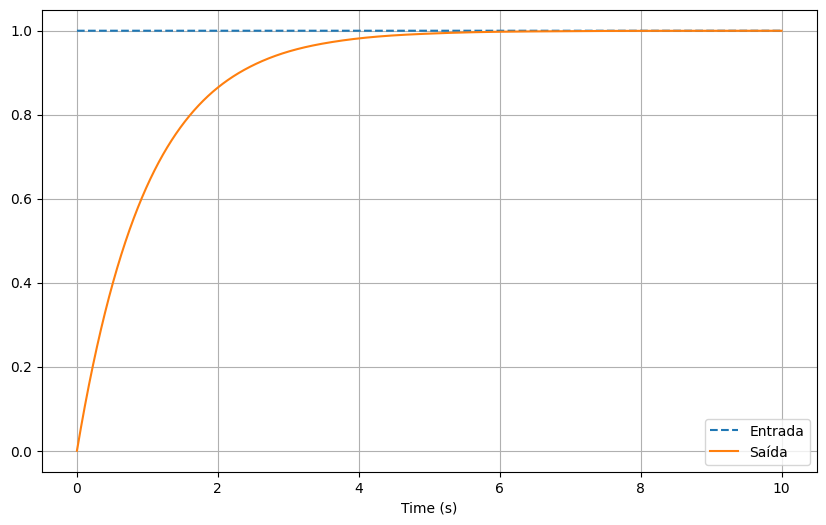

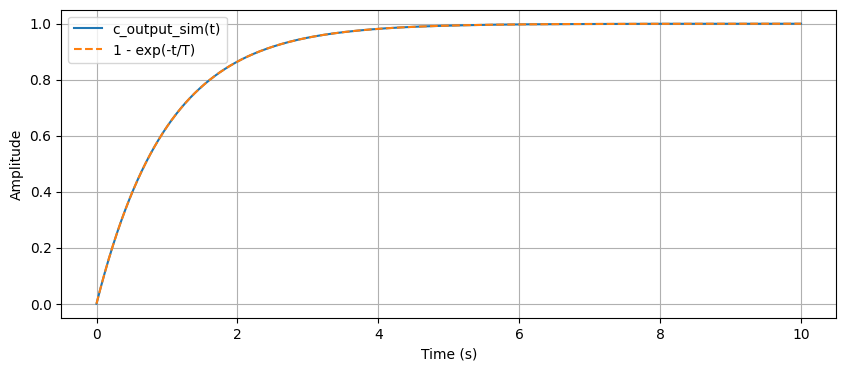

In [10]:
print("Entrada de plot_signals(): t, u_signals_sim, input_blocks_sim, output_out, data")
print("Saída de plot_signals(): figura com u(t) e c(t)")
plot_signals(t, u_signals_sim, input_blocks_sim, output_out, data)

plt.figure(figsize=(10, 4))
plt.plot(t, c_output_sim, label="c_output_sim(t)")
plt.plot(t, c_output_analytic, "--", label="1 - exp(-t/T)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

### Etapa 10 — Integração com o notebook via `open_gui(...)`

Função usada: `open_gui(diagram_path=None, port=8000, width="100%", height=700)`.

A chamada

```python
open_gui("diagrams/first_order_step.json")
```

incorpora a interface visual do CSSIM ao notebook. Essa etapa não altera a matemática do problema, mas facilita a ligação entre:

- a representação gráfica do sistema;
- sua formulação matemática;
- os resultados da simulação.

In [11]:
%matplotlib widget
from cssim import open_gui
open_gui("diagrams/first_order_step.json")

T = 1

## Fechamento do exemplo

### Resumo matemático global do CSSIM

Em uma forma geral, o CSSIM trabalha com duas camadas acopladas. Primeiro, a camada algébrica:

$$
\mathbf{w}(t)=\mathbf{M}^{-1}\bigl(\mathbf{H}\,\mathbf{x}(t)+\mathbf{P}\,\mathbf{u}(t)\bigr).
$$

Depois, a camada dinâmica:

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}_w\,\mathbf{w}(t)+\mathbf{B}_u\,\mathbf{u}(t).
$$

Substituindo a primeira na segunda, e usando $\mathbf{A}$ e $\mathbf{B}$ para denotar as matrizes equivalentes do sistema completo, obtemos a forma padrão de simulação:

$$
\dot{\mathbf{x}}(t)=\mathbf{A}\,\mathbf{x}(t)+\mathbf{B}\,\mathbf{u}(t).
$$

Se desejado, a saída externa pode ser escrita como

$$
\mathbf{y}(t)=\mathbf{C}\,\mathbf{x}(t)+\mathbf{D}\,\mathbf{u}(t).
$$

### Consolidação do sistema de primeira ordem

No exemplo deste notebook, a malha pode ser resumida pelas equações

$$
e(t)=r(t)-c(t),
$$

$$
\dot{x}(t)=e(t),
$$

$$
c(t)=\frac{1}{T}x(t).
$$

Eliminando as variáveis intermediárias, obtemos

$$
\dot{x}(t)=r(t)-\frac{1}{T}x(t).
$$

Em termos da saída,

$$
T\dot{c}(t)+c(t)=r(t).
$$

No domínio de Laplace,

$$
\frac{C(s)}{R(s)}=\frac{1}{Ts+1}.
$$

Para um degrau unitário e condições iniciais nulas,

$$
c(t)=1-e^{-t/T}.
$$

Quando $T=1$, o resultado fica

$$
c(t)=1-e^{-t}.
$$

### Conclusão

O notebook agora fica organizado assim: primeiro a fundamentação teórica; depois o exemplo de primeira ordem construído passo a passo; e, por fim, uma consolidação matemática do resultado obtido por simulação.

Assim, o CSSIM conecta de forma natural três perspectivas do mesmo sistema:

- a estrutura do diagrama de blocos;
- a teoria de espaço de estados;
- a resposta temporal obtida por simulação.